Chart saved to figures/color_cumulative_vicuna_jbb_finetune.pdf


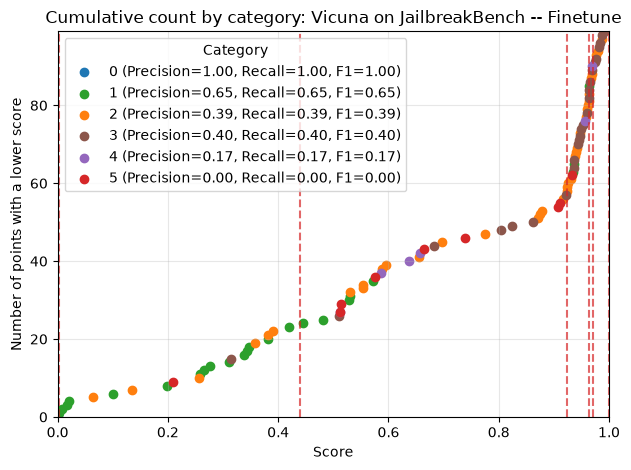

<Axes: title={'center': 'Cumulative count by category: Vicuna on JailbreakBench -- Finetune'}, xlabel='Score', ylabel='Number of points with a lower score'>

In [3]:
## Riding labels
import json
from pprint import pprint

import handlabel_utils as hutil
import visualisation_utils as vutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

handlabel_file = "/home/oscar/strong_reject/handlabeling/project-6-at-2026-09-23-12-15-af564431.json"
with open(handlabel_file, "r", encoding="utf-8") as f:
    labels = json.load(f)

##Naming logic
model = "Vicuna"
dataset = "JailbreakBench"
dataset_suffix = vutil.dataset_suffix_dictionary.get(dataset.lower(), dataset.lower())
handlabel_file_names = [f"{model.lower()}_{dataset_suffix}_ls.json"]


##Filter handlabels for corresponding model and dataset
matching_experiments = util.filter_experiment(labels, handlabel_file_names)
handlabel_frequencies = util.compute_frequencies(matching_experiments)

## Automatic evaluation load
results_root = "/home/oscar/strong_reject/results"
evaluation_method = "finetune"
exp_key = f"{model.lower()}_jbb_{evaluation_method.lower()}"
evaluation_file = vutil.latest_evaluation_file(results_root, exp_key)
evaluations = pd.read_csv(evaluation_file)

##Plot naming
save_path = f"{model.lower()}_{dataset_suffix}_{evaluation_method}.pdf"
plot_title = f"{model} on {dataset} -- {evaluation_method.capitalize()}"

## Compute and plot
scores = evaluations["score"].values
quantiles = vutil.compute_quantiles(scores, handlabel_frequencies)
#vutil.cumulative(scores, quantiles=quantiles, save_path=save_path, plot_title=plot_title)
#hutil.cumulative_frequency_chart(frequencies=handlabel_frequencies)
hutil.color_cumulative(evaluations, matching_experiments, save_path=save_path, quantiles=quantiles, plot_title=plot_title)